# Many Agents and Many Apples - Predicting the Nearest Agent to the Apple using a CNN

### Parameters

In [1]:
# Misc
SEED = 42
OUTPUT_FILE = "new_code_results.csv"

# Data Parameters
TOTAL_TRAIN_SAMPLES = 32000
TOTAL_TEST_SAMPLES = 20000
WIDTH = 6
HEIGHT = 6
NUM_AGENTS = 2
S_TARGET = 1
PROBABILITY_AN_APPLE_IS_PICKED = 0.5

# Training Parameters
NUM_EPOCHS = 1
BATCH_SIZE = 32
LEARNING_RATE = 0.01

# Model Parameters
MLP_HIDDEN_FEATURES = 128
MLP_HIDDEN_LAYERS = 2


### Set the seed

In [2]:
import random
import numpy as np
import torch

def set_seed(seed_value):
    """Sets the seed for reproducibility."""
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed_value)
        # The two lines below are for ensuring deterministic behavior on GPU
        # but can sometimes have a performance cost.
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

# Set the seed for your experiment
set_seed(SEED)

### Imports

In [3]:
from pathlib import Path
import pickle
import sys
import os
import random
import numpy as np
import sys
import torch
from tqdm import tqdm
import os
import matplotlib.pyplot as plt

sys.path.append('../')
# Add the root directory to the Python path to find your modules

from models.reward_cnn import RewardCNNDecentralized

--- PyTorch is configured to use: cpu ---


# Generate Data

- Self-agent is always at index 0
- With probability p_pick, an apple is picked
- If an apple is picked, pick uniformly at random the agent id picker_id that picks apple and we ensure an apple is at picker_id's position, and no other agent can be in the same cell as an apple. The reward for self-agent is euclid_dist(self-agent's position - picker_id's position) if self-agent does not pick apple, and -1 if it did pick apple.
- If no apple is picked, self-agent get reward of 0


In [4]:
import numpy as np
from tqdm import tqdm
import random

def generate_probabilistic_apple_distance_dataset(num_samples, width, height, num_agents, s_target, p_pick=0.5):
    """
    Generates a dataset using the "credit assignment" reward logic.
    - If an apple is picked, the picker gets a reward of -1.
    - A total reward of 2.0 is distributed among all other agents, proportional to their
      Euclidean distance from the picker.
    - This function calculates and returns the final reward for the "self-agent" (agent 0).
    """
    dataset = []
    total_cells = width * height
    all_coords_flat = np.arange(total_cells)

    p_cell = (num_agents / total_cells) * s_target if total_cells > 0 else 0

    for _ in tqdm(range(num_samples), desc=f"Generating {num_samples} samples"):
        agents_grid = np.zeros((height, width), dtype=np.int8)
        apples_grid = np.zeros((height, width), dtype=np.int8)

        # 1. Place all agents, ensuring unique positions
        agent_indices_flat = np.random.choice(all_coords_flat, size=num_agents, replace=False)
        agent_rows, agent_cols = np.unravel_index(agent_indices_flat, (height, width))
        agents_grid[agent_rows, agent_cols] = 1
        
        # Combine into a list of (row, col) positions
        all_agent_positions = np.column_stack((agent_rows, agent_cols))
        
        # The "self-agent" is always the one at index 0
        self_agent_pos = tuple(all_agent_positions[0])

        if np.random.rand() < p_pick:
            # --- SCENARIO 1: ONE AGENT PICKS AN APPLE ---
            
            picker_index = np.random.randint(0, num_agents)
            picker_pos = tuple(all_agent_positions[picker_index])

            # (Apple spawning logic remains the same)
            spawn_mask = np.random.rand(height, width) < p_cell
            spawn_mask[picker_pos] = True
            other_agents_mask = (agents_grid == 1)
            other_agents_mask[picker_pos] = False
            spawn_mask[other_agents_mask] = False
            apples_grid[spawn_mask] = 1

            if picker_index == 0:  # Self-agent is the picker
                reward = -1.0
            else:
                # Calculate distances from ALL agents to the picker
                distances = np.linalg.norm(all_agent_positions - np.array(picker_pos), axis=1)
                sum_of_distances = np.sum(distances)
                
                if sum_of_distances > 1e-6: # Avoid division by zero
                    # Get the self-agent's distance (it's at index 0)
                    self_agent_distance = distances[0]
                    # Calculate its proportional share of the 2.0 reward pool
                    reward = 2 * (self_agent_distance / sum_of_distances)
                else:
                    # This case is rare (all agents at the same spot as picker)
                    reward = 0.0

        else:
            # --- SCENARIO 2: NO AGENT PICKS AN APPLE (Unchanged) ---
            spawn_mask = np.random.rand(height, width) < p_cell
            spawn_mask[agents_grid == 1] = False
            apples_grid[spawn_mask] = 1
            reward = 0.0
            
        state = {'agents': agents_grid, 'apples': apples_grid}
        dataset.append({'state': state, 'agent_pos': self_agent_pos, 'reward': reward})
        
    return dataset

# Data

In [5]:
training_data = generate_probabilistic_apple_distance_dataset(
    TOTAL_TRAIN_SAMPLES, 
    WIDTH, HEIGHT, NUM_AGENTS, S_TARGET, PROBABILITY_AN_APPLE_IS_PICKED)
testing_data = generate_probabilistic_apple_distance_dataset(
    TOTAL_TEST_SAMPLES, WIDTH, HEIGHT, NUM_AGENTS, S_TARGET, PROBABILITY_AN_APPLE_IS_PICKED)

Generating 20000 samples: 100%|██████████| 20000/20000 [00:01<00:00, 13907.71it/s]


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def visualize_state_counts(data, show_zeros=False, highlight_agent_pos=True, cell_fontsize=12, figsize=None):
    """
    Visualize agents and apples as separate numeric grids.
    - data: one entry like training_data[0]
    - show_zeros: if True, prints '0' for empty cells; otherwise leaves them blank
    - highlight_agent_pos: draws a green border around agent_pos cell
    - cell_fontsize: font size for numbers
    - figsize: tuple (w,h) to override default figure size
    (0,0) is top-left; first coord = row (down), second = column (right).
    """
    state = data['state']
    agents = np.array(state['agents'], dtype=int)
    apples = np.array(state['apples'], dtype=int)
    agent_pos = tuple(int(x) for x in data['agent_pos'])
    reward = float(data['reward'])
    rows, cols = agents.shape

    if figsize is None:
        figsize = (max(6, cols * 0.5 * 2), max(4, rows * 0.5))

    fig, axes = plt.subplots(1, 2, figsize=figsize)
    grids = [(agents, "Agents (counts)"), (apples, "Apples (counts)")]

    for ax, (grid, title) in zip(axes, grids):
        # Set coordinate system so (0,0) is top-left
        ax.set_xlim(-0.5, cols - 0.5)
        ax.set_ylim(-0.5, rows - 0.5)
        ax.invert_yaxis()  # this makes row 0 appear at top
        ax.set_xticks(np.arange(cols))
        ax.set_yticks(np.arange(rows))
        ax.set_xticklabels(np.arange(cols))
        ax.set_yticklabels(np.arange(rows))
        ax.set_aspect('equal')
        ax.set_title(title)

        # draw each cell and the number (if nonzero or show_zeros)
        for r in range(rows):
            for c in range(cols):
                # white cell with black border
                rect = Rectangle((c - 0.5, r - 0.5), 1, 1, facecolor='white', edgecolor='black', linewidth=0.8)
                ax.add_patch(rect)
                val = int(grid[r, c])
                if show_zeros or val != 0:
                    ax.text(c, r, str(val), ha='center', va='center', fontsize=cell_fontsize)

        # highlight the agent_pos cell (green border)
        if highlight_agent_pos:
            ar, ac = agent_pos
            if 0 <= ar < rows and 0 <= ac < cols:
                hl = Rectangle((ac - 0.5, ar - 0.5), 1, 1, facecolor='none', edgecolor='green', linewidth=2)
                ax.add_patch(hl)

    fig.suptitle(f"Agent position: {agent_pos}    Reward: {reward:.3f}", fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    return fig, axes


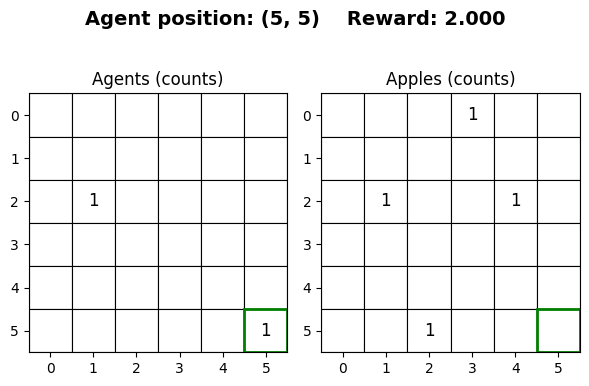

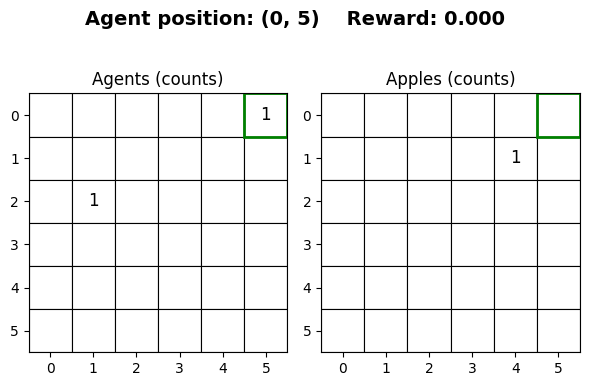

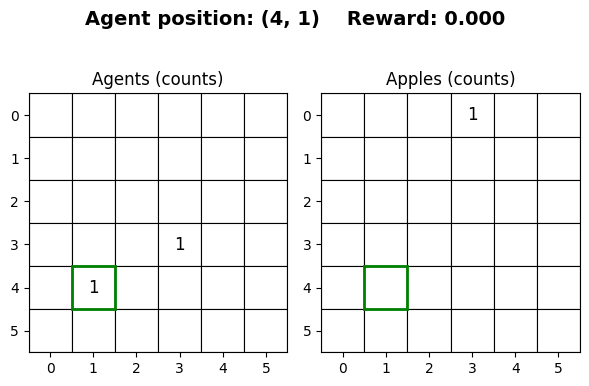

In [7]:
for i in range(3):
    visualize_state_counts(training_data[i])

In [8]:
model = RewardCNNDecentralized(WIDTH, HEIGHT, LEARNING_RATE, mlp_hidden_features=MLP_HIDDEN_FEATURES, num_mlp_hidden_layers=MLP_HIDDEN_LAYERS)
for epoch in range(NUM_EPOCHS):
    print(f"--- Starting Epoch {epoch+1}/{NUM_EPOCHS} ---")
    # Shuffle the training data at the beginning of each epoch
    random.shuffle(training_data)

    # Use tqdm for a progress bar over the batches
    progress_bar = tqdm(range(0, TOTAL_TRAIN_SAMPLES, BATCH_SIZE), desc=f"Epoch {epoch+1} Training")

    for i in progress_bar:
        # Get a slice of the data for the current mini-batch
        batch = training_data[i : i + BATCH_SIZE]
        
        # Process each sample in the mini-batch
        for sample in batch:
            state = sample['state']
            agent_pos = sample['agent_pos']
            reward = sample['reward']
            
            # Add experience to the model's internal buffer
            model.add_experience_from_raw(state, reward, agent_pos=agent_pos)

        # After processing the whole batch, perform one training step
        loss = model.train_batch()
        
        # Update the progress bar with the latest loss
        if loss is not None:
            progress_bar.set_postfix(loss=f"{loss:.4f}")

--- Starting Epoch 1/1 ---


Epoch 1 Training: 100%|██████████| 1000/1000 [00:17<00:00, 56.92it/s, loss=0.0019]


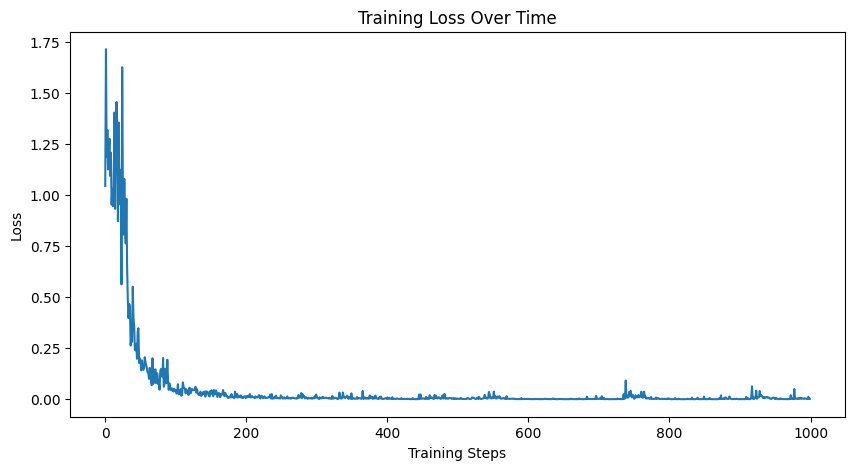

final training loss: 0.0018937685526907444


In [9]:
# PLOT TRAINING LOSS
plt.figure(figsize=(10, 5))
plt.plot(model.loss_history, label='Training Loss')
plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.title('Training Loss Over Time')
plt.show()

print("final training loss:", model.loss_history[-1])

# TEST MODEL

In [10]:
# --- Step 2: Initialize Variables for Metrics ---
abs_overall_errors = [] # We'll store all the absolute errors to calculate MAE and RMSE efficiently

rel_errors_when_reward_bigger_than_0 = []  # Store errors when true reward is greater than 0
abs_errors_when_reward_minus_one = []  # Store errors when true reward is -1
abs_errors_when_reward_zero = []  # Store errors when true reward is 0

# --- Step 3: The Evaluation Loop ---
print("\n--- Starting Evaluation on Test Set ---")
# No need to shuffle the test set.
for sample in tqdm(testing_data, desc="Evaluating"):
    state = sample['state']
    agent_pos = sample['agent_pos']
    true_reward = sample['reward']
    
    # Get the model's prediction. The .item() is important to get a single float.
    predicted_reward = model.get_model_reward_prediction_from_raw(state, agent_pos=agent_pos).item()
    
    # Calculate the absolute error
    error = abs(predicted_reward - true_reward)
    abs_overall_errors.append(error)
    if true_reward > 0:
        rel_errors_when_reward_bigger_than_0.append(abs((error / true_reward)))  # Relative error
    if true_reward == -1:
        abs_errors_when_reward_minus_one.append(error)
    if true_reward == 0:
        abs_errors_when_reward_zero.append(error)




--- Starting Evaluation on Test Set ---


Evaluating: 100%|██████████| 20000/20000 [00:13<00:00, 1443.84it/s]


In [11]:
MAPE_positive = (np.mean(rel_errors_when_reward_bigger_than_0) * 100) if rel_errors_when_reward_bigger_than_0 else 0
MAE_overall = np.mean(abs_overall_errors)
MAE_reward_minus_1 = np.mean(abs_errors_when_reward_minus_one) if abs_errors_when_reward_minus_one else 0
MAE_reward_0 = np.mean(abs_errors_when_reward_zero) if abs_errors_when_reward_zero else 0

In [12]:
print("MAPE (true reward > 0):", MAPE_positive)
print("MAE (overall):", MAE_overall)
print("MAE (true reward = -1):", MAE_reward_minus_1)
print("MAE (true reward = 0):", MAE_reward_0)

MAPE (true reward > 0): 3.7221327520967495
MAE (overall): 0.029888844293914734
MAE (true reward = -1): 0.02897935112317403
MAE (true reward = 0): 0.008536693754939862
